In [ ]:
# ====== Step 1: Import Libraries ======
import os
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from google.colab import drive

# ====== Step 2: Mount Google Drive ======
drive.mount('/content/drive')

# ====== Step 3: Define Dataset Path ======
train_dir = "/content/drive/My Drive/pest/train"
test_dir = "/content/drive/My Drive/pest/test"

# ====== Step 4: Load Dataset ======
batch_size = 32
img_size = (380, 380)

train_dataset = image_dataset_from_directory(train_dir, shuffle=True, image_size=img_size, batch_size=batch_size)
test_dataset = image_dataset_from_directory(test_dir, shuffle=False, image_size=img_size, batch_size=batch_size)

num_classes = len(train_dataset.class_names)
print("Number of classes:", num_classes)

# ====== Step 5: Normalize Data ======
preprocess_input = tf.keras.applications.efficientnet.preprocess_input
train_dataset = train_dataset.map(lambda x, y: (preprocess_input(x), y))
test_dataset = test_dataset.map(lambda x, y: (preprocess_input(x), y))

# ====== Step 6: Define Model ======
base_model = EfficientNetB4(weights="imagenet", include_top=False, input_shape=(380, 380, 3))
base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.4)(x)
x = Dense(512, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

# ====== Step 7: Compile & Train Phase 1 ======
model.compile(optimizer=Adam(0.0005), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
print("Training top layers...")
history = model.fit(train_dataset, validation_data=test_dataset, epochs=15)

# ====== Step 8: Fine-tune Model ======
base_model.trainable = True
model.compile(optimizer=Adam(0.00001), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
print("Fine-tuning entire model...")
history_finetune = model.fit(train_dataset, validation_data=test_dataset, epochs=10)

# ====== Step 9: Save Model ======
model.save("/content/drive/My Drive/deeppestNet_model.h5")
print("✅ Model saved successfully!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 2730 files belonging to 9 classes.
Found 460 files belonging to 9 classes.
Number of classes: 9
Training top layers...
Epoch 1/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 116s 802ms/step - accuracy: 0.6469 - loss: 1.1086 - val_accuracy: 0.9391 - val_loss: 0.2388
Epoch 2/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 78s 321ms/step - accuracy: 0.9362 - loss: 0.2275 - val_accuracy: 0.9761 - val_loss: 0.1317
Epoch 3/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 26s 296ms/step - accuracy: 0.9677 - loss: 0.1288 - val_accuracy: 0.9761 - val_loss: 0.1075
Epoch 4/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 42s 306ms/step - accuracy: 0.9822 - loss: 0.0803 - val_accuracy: 0.9848 - val_loss: 0.0873
Epoch 5/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 41s 303ms/step - accuracy: 0.9877 - loss: 0.0570 - val_accuracy: 0.9804 - val_loss: 0.0887
Epoch 6/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 41s 308ms/step - accuracy: 0.9952 - loss: 0.0394 - val_accurac

✅ Model saved successfully!


In [1]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


Saving jpg_4.jpg to jpg_4.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
✅ Predicted Pest: Beetle
🧪 Recommended Pesticide: Carbaryl


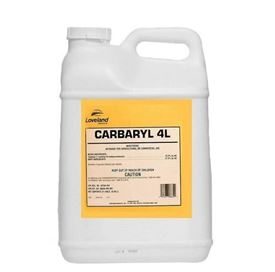

In [ ]:

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input
import numpy as np
from PIL import Image as PILImage
from IPython.display import Image, display
from google.colab import files


class_labels = {
    0: {'pest': 'aphid', 'pesticide': 'Imidacloprid', 'image': '/content/drive/My Drive/pesticide_images/aphid_pesticide.jpg'},
    1: {'pest': 'armyworm', 'pesticide': 'Lambda-cyhalothrin', 'image': '/content/drive/My Drive/pesticide_images/armyworm_pesticide.jpg'},
    2: {'pest': 'beetle', 'pesticide': 'Carbaryl', 'image': '/content/drive/My Drive/pesticide_images/beetle_pesticide.jpeg'},
    3: {'pest': 'bollworm', 'pesticide': 'Chlorpyrifos', 'image': '/content/drive/My Drive/pesticide_images/bollworm_pesticide.jpeg'},
    4: {'pest': 'grasshopper', 'pesticide': 'Malathion', 'image': '/content/drive/My Drive/pesticide_images/grasshopper_pesticide.jpeg'},
    5: {'pest': 'mites', 'pesticide': 'Abamectin', 'image': '/content/drive/My Drive/pesticide_images/mites_pesticide.jpg'},
    6: {'pest': 'mosquito', 'pesticide': 'Temephos', 'image': '/content/drive/My Drive/pesticide_images/mosquito_pesticide.jpeg'},
    7: {'pest': 'sawfly', 'pesticide': 'Spinosad', 'image': '/content/drive/My Drive/pesticide_images/sawfly_pesticide.jpeg'},
    8: {'pest': 'stem_borer', 'pesticide': 'Quinalphos', 'image': '/content/drive/My Drive/pesticide_images/stem_borer_pesticide.jpg'}
}

model_path = '/content/drive/My Drive/deeppestNet_model.h5'

model = load_model(model_path)


def predict_pest(img_path):
    img = image.load_img(img_path, target_size=(380, 380))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    preds = model.predict(x)
    predicted_class = np.argmax(preds[0])

    pest_info = class_labels[predicted_class]

    print(f"✅ Predicted Pest: {pest_info['pest'].capitalize()}")
    print(f"🧪 Recommended Pesticide: {pest_info['pesticide']}")
    display(Image(filename=pest_info['image']))
uploaded = files.upload()

for filename in uploaded.keys():
    predict_pest(filename)


📤 Upload pest image(s) for prediction:


Saving jpg_8.jpg to jpg_8.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step

📷 Image: jpg_8.jpg
✅ Predicted Pest: Beetle
🧪 Recommended Pesticide: Carbaryl


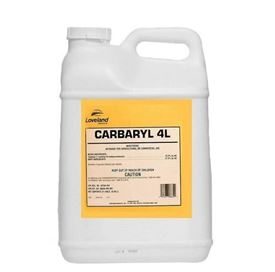

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input
import numpy as np
from PIL import Image as PILImage
from IPython.display import Image, display
from google.colab import files
import os

# Mapping class indices to pest details
class_labels = {
    0: {'pest': 'aphid', 'pesticide': 'Imidacloprid', 'image': '/content/drive/My Drive/pesticide_images/aphid_pesticide.jpg'},
    1: {'pest': 'armyworm', 'pesticide': 'Lambda-cyhalothrin', 'image': '/content/drive/My Drive/pesticide_images/armyworm_pesticide.jpg'},
    2: {'pest': 'beetle', 'pesticide': 'Carbaryl', 'image': '/content/drive/My Drive/pesticide_images/beetle_pesticide.jpeg'},
    3: {'pest': 'bollworm', 'pesticide': 'Chlorpyrifos', 'image': '/content/drive/My Drive/pesticide_images/bollworm_pesticide.jpeg'},
    4: {'pest': 'grasshopper', 'pesticide': 'Malathion', 'image': '/content/drive/My Drive/pesticide_images/grasshopper_pesticide.jpeg'},
    5: {'pest': 'mites', 'pesticide': 'Abamectin', 'image': '/content/drive/My Drive/pesticide_images/mites_pesticide.jpg'},
    6: {'pest': 'mosquito', 'pesticide': 'Temephos', 'image': '/content/drive/My Drive/pesticide_images/mosquito_pesticide.jpeg'},
    7: {'pest': 'sawfly', 'pesticide': 'Spinosad', 'image': '/content/drive/My Drive/pesticide_images/sawfly_pesticide.jpeg'},
    8: {'pest': 'stem_borer', 'pesticide': 'Quinalphos', 'image': '/content/drive/My Drive/pesticide_images/stem_borer_pesticide.jpg'}
}

# Load the model only once
model_path = '/content/drive/My Drive/deeppestNet_model.h5'
model = load_model(model_path)


# Prediction function
def predict_pest(img_path):
    img = image.load_img(img_path, target_size=(380, 380))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    preds = model.predict(x)
    predicted_class = np.argmax(preds[0])
    pest_info = class_labels[predicted_class]

    print(f"\n📷 Image: {os.path.basename(img_path)}")
    print(f"✅ Predicted Pest: {pest_info['pest'].capitalize()}")
    print(f"🧪 Recommended Pesticide: {pest_info['pesticide']}")
    display(Image(filename=pest_info['image']))


# Upload and auto-predict
print("📤 Upload pest image(s) for prediction:")
uploaded = files.upload()

for filename in uploaded:
    predict_pest(filename)


In [ ]:
# ====== Step 1: Import Libraries ======
import os
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from google.colab import drive

# ====== Step 2: Mount Google Drive ======
drive.mount('/content/drive')

# ====== Step 3: Define Dataset Path ======
train_dir = "/content/drive/My Drive/pest/train"
test_dir = "/content/drive/My Drive/pest/test"

# ====== Step 4: Load Dataset ======
batch_size = 32
img_size = (380, 380)

train_dataset = image_dataset_from_directory(train_dir, shuffle=True, image_size=img_size, batch_size=batch_size)
test_dataset = image_dataset_from_directory(test_dir, shuffle=False, image_size=img_size, batch_size=batch_size)

num_classes = len(train_dataset.class_names)
print("Number of classes:", num_classes)

# ====== Step 5: Normalize Data ======
preprocess_input = tf.keras.applications.efficientnet.preprocess_input
train_dataset = train_dataset.map(lambda x, y: (preprocess_input(x), y))
test_dataset = test_dataset.map(lambda x, y: (preprocess_input(x), y))

# ====== Step 6: Define Model ======
base_model = EfficientNetB4(weights="imagenet", include_top=False, input_shape=(380, 380, 3))
base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.4)(x)
x = Dense(512, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

# ====== Step 7: Compile & Train Phase 1 ======
model.compile(optimizer=Adam(0.0005), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
print("Training top layers...")
history = model.fit(train_dataset, validation_data=test_dataset, epochs=5)

# ====== Step 8: Fine-tune Model ======
base_model.trainable = True
model.compile(optimizer=Adam(0.00001), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
print("Fine-tuning entire model...")
history_finetune = model.fit(train_dataset, validation_data=test_dataset, epochs=3)

# ====== Step 9: Save Model ======
model.save("/content/drive/My Drive/deeppestNet_model.h5")
print("✅ Model saved successfully!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 2730 files belonging to 9 classes.
Found 460 files belonging to 9 classes.
Number of classes: 9
71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training top layers...
Epoch 1/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 1067s 12s/step - accuracy: 0.6410 - loss: 1.1281 - val_accuracy: 0.9196 - val_loss: 0.2480
Epoch 2/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 81s 290ms/step - accuracy: 0.9376 - loss: 0.2417 - val_accuracy: 0.9630 - val_loss: 0.1430
Epoch 3/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 40s 277ms/step - accuracy: 0.9657 - loss: 0.1328 - val_accuracy: 0.9696 - val_loss: 0.1172
Epoch 4/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 41s 280ms/step - accuracy: 0.9720 - loss: 0.0933 - val_accuracy: 0.9761 - val_loss: 0.1021
Epoch 5/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 42s 296ms/step - accuracy: 0.9875 - loss: 0.0586 - val_accuracy: 0.9783 - val_loss: 0.0966
Fine-tuning entire model...
Epoch 1/3
86/86 ━━━━━━━━━━━

✅ Model saved successfully!


In [ ]:
# Check if the history object exists
print(history.history.keys())


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


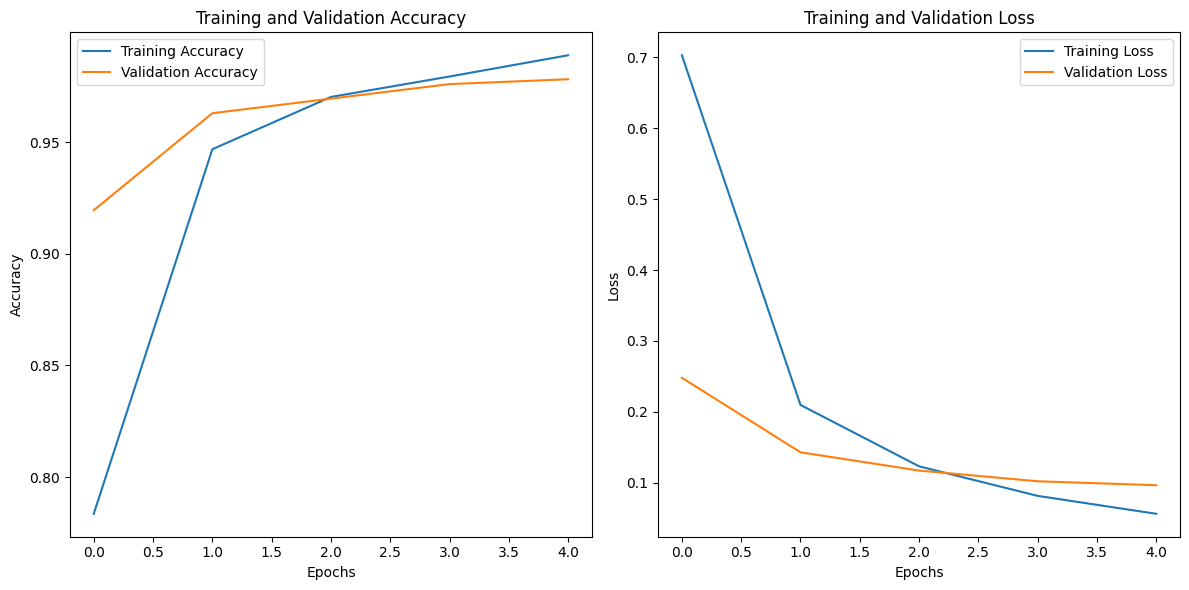

In [ ]:
import matplotlib.pyplot as plt


print(history.history.keys())


plt.figure(figsize=(12, 6))

# Plot Training and Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

# Plot Training and Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Display the plots
plt.tight_layout()
plt.show()


Found 2730 files belonging to 9 classes.
Found 460 files belonging to 9 classes.
Number of classes: 9
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


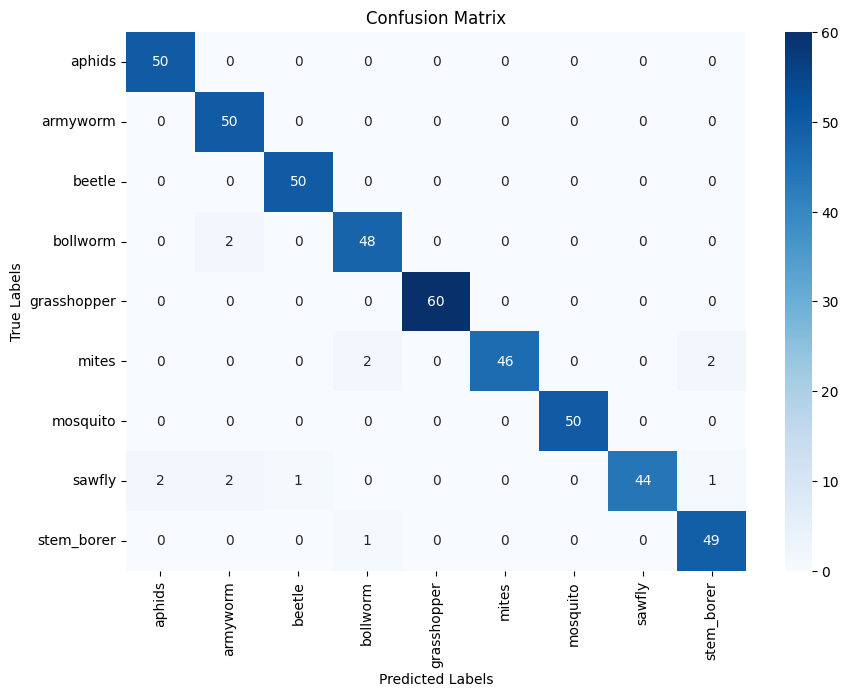

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
train_dir = "/content/drive/My Drive/pest/train"
test_dir = "/content/drive/My Drive/pest/test"


batch_size = 32
img_size = (380, 380)

train_dataset = image_dataset_from_directory(train_dir, shuffle=True, image_size=img_size, batch_size=batch_size)
test_dataset = image_dataset_from_directory(test_dir, shuffle=False, image_size=img_size, batch_size=batch_size)

num_classes = len(train_dataset.class_names)
print("Number of classes:", num_classes)


class_names = train_dataset.class_names
y_true = []
y_pred = []


for images, labels in test_dataset:

    y_true.extend(labels.numpy())


    predictions = model.predict(images)
    y_pred.extend(np.argmax(predictions, axis=1))


cm = confusion_matrix(y_true, y_pred)


plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
Accuracy: 97.17%
Classification Report:
               precision    recall  f1-score   support

      aphids       0.96      1.00      0.98        50
    armyworm       0.93      1.00      0.96        50
      beetle       0.98      1.00      0.99        50
    bollworm       0.94      0.96      0.95        50
 grasshopper       1.00      1.00      1.00        60
       mites       1.00      0.92      0.96      

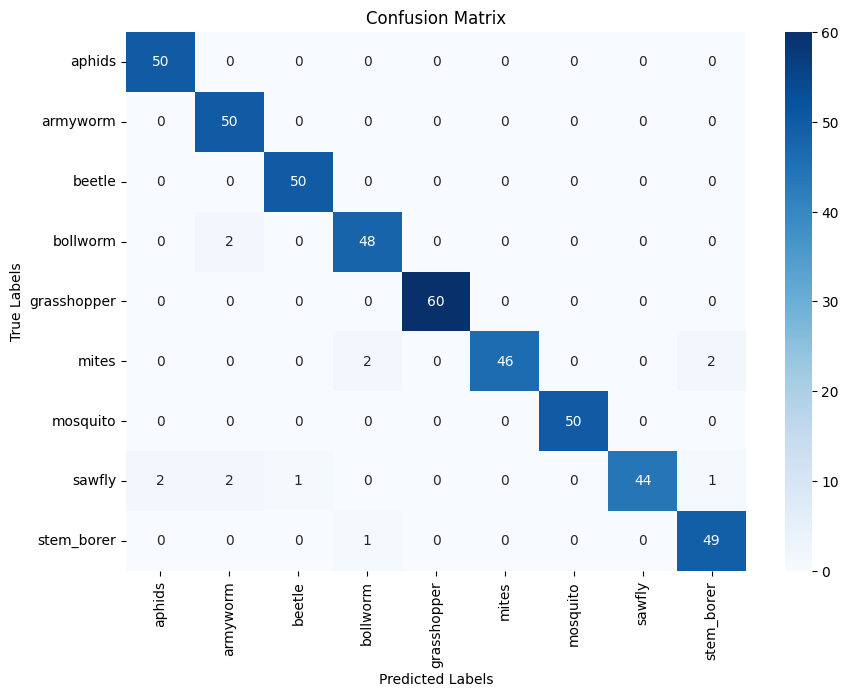

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


y_true = []
y_pred = []

for images, labels in test_dataset:

    y_true.extend(labels.numpy())


    predictions = model.predict(images)
    y_pred.extend(np.argmax(predictions, axis=1))


accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")


report = classification_report(y_true, y_pred, target_names=train_dataset.class_names)
print("Classification Report:\n", report)


cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)


plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=train_dataset.class_names, yticklabels=train_dataset.class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()
